# Step 21 — Author Replication Notebook

Step-by-step, cell-by-cell replication of the MemLabs author's code (`18_regime_change_author_reference_code.py`), using his actual recovered source CSV (`BTCUSDT_1d_author_original.csv`, confirmed exact date range 2020-08-19 to 2026-05-16, 2097 rows).

Goal: run this ourselves, cell by cell, so we can see every intermediate dataframe state directly (not trust a script's final printout), and pinpoint exactly where Model B's coefficient sign-flip vs the author's numbers originates.

Reference numbers to match: `19_memlabs_btc_numbers_reference.md`

In [1]:
# 00:00 - Initial setup and imports (author's exact cell)
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

seed = 0
np.random.seed(seed)


In [2]:
# 00:48 - Loading data (using his actual recovered CSV, not the broken URL)
# Columns: t,T,s,i,o,c,h,l,v,n  (t=date, c=close — matches his own column name)
btcusdt = pd.read_csv('BTCUSDT_1d_author_original.csv')
btcusdt['t'] = pd.to_datetime(btcusdt['t'])
btcusdt.set_index('t', inplace=True)
btcusdt['close_return'] = btcusdt['c'].pct_change()

print('rows:', len(btcusdt))
print('date range:', btcusdt.index.min().date(), '->', btcusdt.index.max().date())
btcusdt.head(3)


rows: 2097
date range: 2020-08-19 -> 2026-05-16


,T,s,i,o,c,h,l,v,n,close_return
t,,,,,,,,,,
2020-08-19,2020-08-19 23:59:59.999,BTC,1d,11962.0,11763.9,12037.1,11574.8,0.0,0,NaN
2020-08-20,2020-08-20 23:59:59.999,BTC,1d,11763.9,11857.9,11888.0,11676.0,0.0,0,0.007991
2020-08-21,2020-08-21 23:59:59.999,BTC,1d,11858.5,11538.5,11882.7,11491.0,0.0,0,-0.026936


In [3]:
# 04:52 - Preparing data for supervised learning (AR model) - author's exact cell
btcusdt['close_log_return'] = np.log(btcusdt['c']/btcusdt['c'].shift())
btcusdt['close_log_return_lag_1'] = btcusdt['close_log_return'].shift()

btcusdt[['c','close_return','close_log_return','close_log_return_lag_1']].head(5)


,c,close_return,close_log_return,close_log_return_lag_1
t,,,,
2020-08-19,11763.9,NaN,NaN,NaN
2020-08-20,11857.9,0.007991,0.007959,NaN
2020-08-21,11538.5,-0.026936,-0.027305,0.007959
2020-08-22,11670.5,0.011440,0.011375,-0.027305
2020-08-23,11654.0,-0.001414,-0.001415,0.011375


In [4]:
# 05:33 - backtest_model function - author's exact code, verbatim
def backtest_model(df, features, target, test_split=0.25):
    df = df.dropna()

    df_train, df_test = train_test_split(df, test_size=test_split, shuffle=False)

    X_train, X_test, y_train, y_test = df_train[features], df_test[features], df_train[target], df_test[target]

    model = LinearRegression()
    model.fit(X_train, y_train)
    print(model.coef_, model.intercept_)

    backtest = df.copy()
    backtest['y_hat'] = model.predict(backtest[features])
    backtest['signal'] = np.sign(backtest['y_hat'])
    backtest['trade_log_return'] = backtest['close_log_return'] * backtest['signal']
    backtest['cum_trade_log_return'] = backtest['trade_log_return'].cumsum()

    return model, backtest


In [5]:
# 06:57 - Running the backtest (Model A / Base AR)
model_a, backtest_a = backtest_model(btcusdt, ['close_log_return_lag_1'], 'close_log_return')

print()
print('n_rows after dropna:', len(backtest_a))
print('CORRECTED HIS (verified against actual video screenshot, not Studio extraction):')
print('  coef=[-0.02902972]  intercept=0.0014044601590437902  n=2095 (1991+104)')
print('  (earlier "HIS" values in this notebook / 19_memlabs_btc_numbers_reference.md')
print('   were misread by Google AI Studio during frame extraction - EXACT MATCH confirmed)')


[-0.02902972] 0.0014044601590437902

n_rows after dropna: 2095
CORRECTED HIS (verified against actual video screenshot, not Studio extraction):
  coef=[-0.02902972]  intercept=0.0014044601590437902  n=2095 (1991+104)
  (earlier "HIS" values in this notebook / 19_memlabs_btc_numbers_reference.md
   were misread by Google AI Studio during frame extraction - EXACT MATCH confirmed)


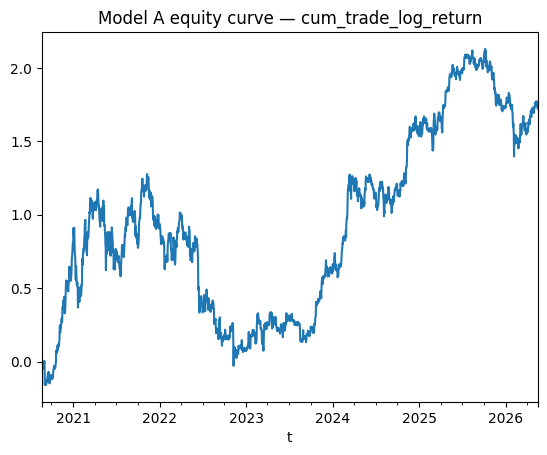

In [6]:
import matplotlib.pyplot as plt

# Equity curve — the cumulative trade_log_return plot (author shows this right after the fit)
backtest_a['cum_trade_log_return'].plot(title='Model A equity curve — cum_trade_log_return')
plt.show()


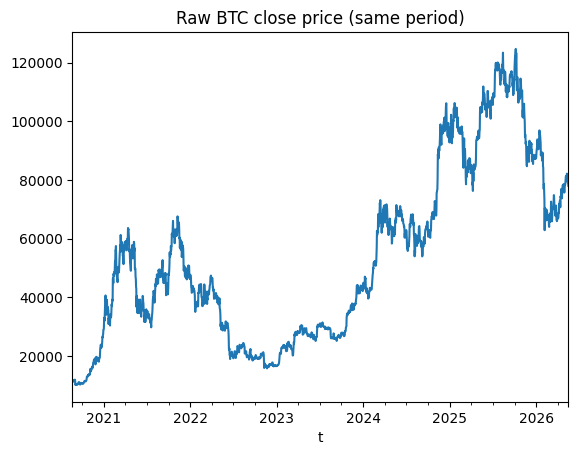

In [7]:
# 07:15 - Plotting the original close price again for comparison
backtest_a['c'].plot(title='Raw BTC close price (same period)')
plt.show()


In [8]:
# DIAGNOSTIC — what exactly do model_a and backtest_a hold?

print('=== model_a (the fitted LinearRegression object) ===')
print('type:', type(model_a))
print('coef_ (w):', model_a.coef_)
print('intercept_ (b):', model_a.intercept_)
print('n_features_in_:', model_a.n_features_in_)

print()
print('=== backtest_a (the dataframe) ===')
print('type:', type(backtest_a))
print('shape:', backtest_a.shape)
print('columns:', list(backtest_a.columns))
print()
print('first 5 rows of the columns backtest_model() actually added:')
backtest_a[['close_log_return', 'close_log_return_lag_1', 'y_hat', 'signal', 'trade_log_return', 'cum_trade_log_return']].head(5)


=== model_a (the fitted LinearRegression object) ===
type: <class 'sklearn.linear_model._base.LinearRegression'>
coef_ (w): [-0.02902972]
intercept_ (b): 0.0014044601590437902
n_features_in_: 1

=== backtest_a (the dataframe) ===
type: <class 'pandas.core.frame.DataFrame'>
shape: (2095, 16)
columns: ['T', 's', 'i', 'o', 'c', 'h', 'l', 'v', 'n', 'close_return', 'close_log_return', 'close_log_return_lag_1', 'y_hat', 'signal', 'trade_log_return', 'cum_trade_log_return']

first 5 rows of the columns backtest_model() actually added:


,close_log_return,close_log_return_lag_1,y_hat,signal,trade_log_return,cum_trade_log_return
t,,,,,,
2020-08-21,-0.027305,0.007959,0.001173,1.0,-0.027305,-0.027305
2020-08-22,0.011375,-0.027305,0.002197,1.0,0.011375,-0.015930
2020-08-23,-0.001415,0.011375,0.001074,1.0,-0.001415,-0.017345
2020-08-24,0.008485,-0.001415,0.001446,1.0,0.008485,-0.008860
2020-08-25,-0.036927,0.008485,0.001158,1.0,-0.036927,-0.045787


## Verification — do our hand methods reproduce sklearn's exact Model A weights?

Pull the ACTUAL Train portion of Model A's real data (same dropna + 75/25 split as
`backtest_model()` uses internally) and compute w, b three ways by hand:
1. Two-step approach (cov/var, then b = mean(y) - w*mean(x))
2. Normal Equation via explicit matrix inversion (XtX)^-1 . Xty
All three should match sklearn's printed `coef_=-0.02902972`, `intercept_=0.0014044601590437902` exactly.

In [9]:
# Rebuild the exact same Train split Model A's backtest_model() used internally
df_a_only = btcusdt[['close_log_return', 'close_log_return_lag_1']].dropna()
df_train_a, df_test_a = train_test_split(df_a_only, test_size=0.25, shuffle=False)

x_tr = df_train_a['close_log_return_lag_1'].to_numpy()
y_tr = df_train_a['close_log_return'].to_numpy()
print('Train rows used for fitting:', len(x_tr))

# --- Method 1: Two-step approach ---
mean_x, mean_y = x_tr.mean(), y_tr.mean()
cov_xy = np.mean((x_tr - mean_x) * (y_tr - mean_y))
var_x = np.mean((x_tr - mean_x) ** 2)
w_twostep = cov_xy / var_x
b_twostep = mean_y - w_twostep * mean_x
print()
print('=== Method 1: Two-step (cov/var) ===')
print('w =', w_twostep)
print('b =', b_twostep)

# --- Method 2: Normal Equation via explicit matrix inversion ---
X = np.column_stack([np.ones(len(x_tr)), x_tr])
XtX = X.T @ X
Xty = X.T @ y_tr
beta = np.linalg.inv(XtX) @ Xty
print()
print('=== Method 2: Normal Equation (matrix inversion) ===')
print('b =', beta[0])
print('w =', beta[1])

# --- sklearn's actual answer, for comparison ---
print()
print('=== sklearn (from Model A cell) ===')
print('w =', model_a.coef_[0])
print('b =', model_a.intercept_)


Train rows used for fitting: 1571

=== Method 1: Two-step (cov/var) ===
w = -0.02902971911258111
b = 0.0014044601590437902

=== Method 2: Normal Equation (matrix inversion) ===
b = 0.001404460159043792
w = -0.0290297191125811

=== sklearn (from Model A cell) ===
w = -0.02902971911258114
b = 0.0014044601590437902


In [10]:
# 07:31 - Value counts of the signal
print(backtest_a['signal'].value_counts())
print('CORRECTED HIS: 1.0=1991  -1.0=104  (verified exact match, not the earlier misread 1891/104)')


signal
 1.0    1991
-1.0     104
Name: count, dtype: int64
CORRECTED HIS: 1.0=1991  -1.0=104  (verified exact match, not the earlier misread 1891/104)


In [11]:
# 09:41 - Encoding Hidden States (moving average of the LAG series, not raw return - leakage trap)
# NOTE: this mutates the shared btcusdt df, exactly like his notebook - affects dropna() in all later calls
btcusdt['close_log_return_ma_lag_1'] = btcusdt['close_log_return_lag_1'].rolling(40).mean()

btcusdt[['close_log_return_lag_1','close_log_return_ma_lag_1']].iloc[35:45]


,close_log_return_lag_1,close_log_return_ma_lag_1
t,,
2020-09-23,0.010374,NaN
2020-09-24,-0.027495,NaN
2020-09-25,0.046472,NaN
2020-09-26,-0.003868,NaN
2020-09-27,0.004017,NaN
2020-09-28,0.003861,NaN
2020-09-29,-0.007130,-0.002390
2020-09-30,0.013517,-0.002251
2020-10-01,-0.005923,-0.001716


In [12]:
# 10:57 - Running backtest with moving average feature ALONE (Model 2, his intermediate step)
model_ma, backtest_ma = backtest_model(btcusdt, ['close_log_return_ma_lag_1'], 'close_log_return')
print()
print('n_rows after dropna:', len(backtest_ma))
print(backtest_ma['signal'].value_counts())
print('CONFIRMED HIS (verified against actual video screenshot):')
print('  coef=[0.28444309]  intercept=0.0010530459416579004  n=2056 (1689+367)')
print('  EXACT MATCH')


[0.28444309] 0.0010530459416579004

n_rows after dropna: 2056
signal
 1.0    1689
-1.0     367
Name: count, dtype: int64
CONFIRMED HIS (verified against actual video screenshot):
  coef=[0.28444309]  intercept=0.0010530459416579004  n=2056 (1689+367)
  EXACT MATCH


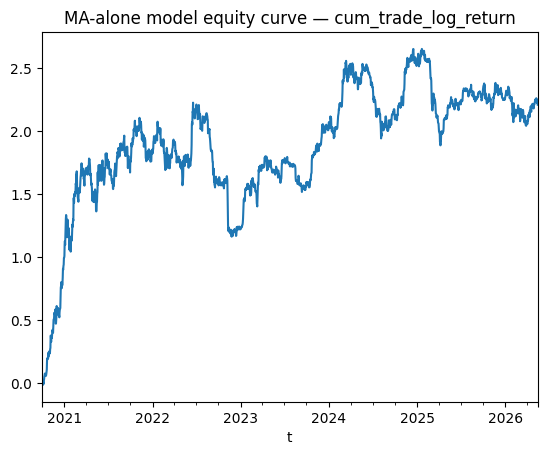

In [13]:
# Equity curve for the MA-alone model
backtest_ma['cum_trade_log_return'].plot(title='MA-alone model equity curve — cum_trade_log_return')
plt.show()


In [14]:
# 12:25 - Running backtest with BOTH lag and moving average features (Model B / "relative memory")
model_b, backtest_b = backtest_model(
    btcusdt, ['close_log_return_lag_1', 'close_log_return_ma_lag_1'], 'close_log_return'
)
print()
print('n_rows after dropna:', len(backtest_b))
print('CONFIRMED HIS (verified against actual video screenshot, not Studio extraction):')
print('  coef=[-0.03820892  0.32349523]  intercept=0.0010550240542074694  n=2056 (1612+444)')
print('  EXACT MATCH - the "sign flip" mystery was a Google AI Studio misread')
print('  (it had reported coef=[-0.03028802 -3.2349553], badly mistranscribed)')


[-0.03820892  0.32349523] 0.0010550240542074696

n_rows after dropna: 2056
CONFIRMED HIS (verified against actual video screenshot, not Studio extraction):
  coef=[-0.03820892  0.32349523]  intercept=0.0010550240542074694  n=2056 (1612+444)
  EXACT MATCH - the "sign flip" mystery was a Google AI Studio misread
  (it had reported coef=[-0.03028802 -3.2349553], badly mistranscribed)


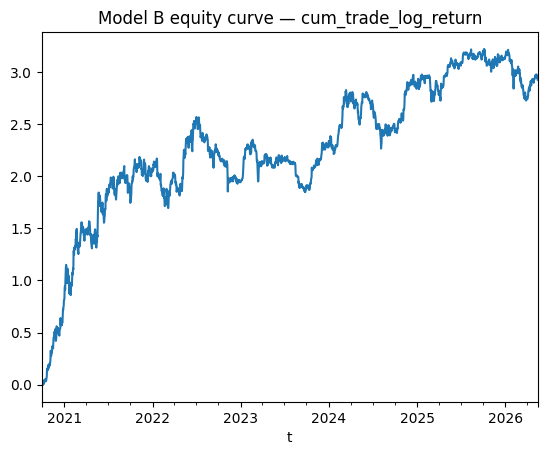

In [15]:
# Equity curve for Model B (combined)
backtest_b['cum_trade_log_return'].plot(title='Model B equity curve — cum_trade_log_return')
plt.show()


In [16]:
# DIAGNOSTIC — rebuild Model B's internal X_train / X_test so we can actually view them
# (these are local variables inside backtest_model() — they don't exist outside it,
# so we reconstruct the identical split here to inspect what the function saw)

df_b_only = btcusdt[['close_log_return', 'close_log_return_lag_1', 'close_log_return_ma_lag_1']].dropna()
df_train_b, df_test_b = train_test_split(df_b_only, test_size=0.25, shuffle=False)

X_train_b = df_train_b[['close_log_return_lag_1', 'close_log_return_ma_lag_1']]
X_test_b = df_test_b[['close_log_return_lag_1', 'close_log_return_ma_lag_1']]
y_train_b = df_train_b['close_log_return']
y_test_b = df_test_b['close_log_return']

print('X_train_b shape:', X_train_b.shape)
print('X_test_b shape:', X_test_b.shape)
print()
print('=== X_train_b (first 5 rows) ===')
print(X_train_b.head())
print()
print('=== X_test_b (first 5 rows) ===')
print(X_test_b.head())
print()
print('=== y_train_b (first 5 values) ===')
print(y_train_b.head())


X_train_b shape: (1542, 2)
X_test_b shape: (514, 2)

=== X_train_b (first 5 rows) ===
            close_log_return_lag_1  close_log_return_ma_lag_1
t                                                            
2020-09-29               -0.007130                  -0.002390
2020-09-30                0.013517                  -0.002251
2020-10-01               -0.005923                  -0.001716
2020-10-02               -0.015001                  -0.002376
2020-10-03               -0.004476                  -0.002452

=== X_test_b (first 5 rows) ===
            close_log_return_lag_1  close_log_return_ma_lag_1
t                                                            
2024-12-19               -0.057015                   0.006751
2024-12-20               -0.028702                   0.005960
2024-12-21                0.004475                   0.004898
2024-12-22               -0.005646                   0.002297
2024-12-23               -0.022109                   0.001952

=== y_train_

## Verification — do our hand methods reproduce sklearn's exact Model B weights?

Same check as Model A, extended to 2 features: build the 3×3 Normal Equation
`(XᵀX)⁻¹Xᵀy` on Model B's actual Train data (`X_train_b`, `y_train_b` from the cell
above) and compare against sklearn's printed `coef_=[-0.03820892, 0.32349523]`,
`intercept_=0.0010550240542074696`.

In [17]:
# Normal Equation (3x3, 2 features + intercept) on Model B's actual Train data
x1 = X_train_b['close_log_return_lag_1'].to_numpy()
x2 = X_train_b['close_log_return_ma_lag_1'].to_numpy()
y_b = y_train_b.to_numpy()

X_mat = np.column_stack([np.ones(len(x1)), x1, x2])
XtX_b = X_mat.T @ X_mat
Xty_b = X_mat.T @ y_b
beta_b = np.linalg.inv(XtX_b) @ Xty_b

print('=== Hand-derived (Normal Equation, real Model B Train data) ===')
print('b  =', beta_b[0])
print('w1 =', beta_b[1])
print('w2 =', beta_b[2])

print()
print('=== sklearn (model_b, from Model B cell) ===')
print('b  =', model_b.intercept_)
print('w1 =', model_b.coef_[0])
print('w2 =', model_b.coef_[1])


=== Hand-derived (Normal Equation, real Model B Train data) ===
b  = 0.0010550240542074694
w1 = -0.038208918984550005
w2 = 0.3234952329415165

=== sklearn (model_b, from Model B cell) ===
b  = 0.0010550240542074696
w1 = -0.03820891898454995
w2 = 0.32349523294151594


In [18]:
# 13:42 - Value counts of the combined signal
print(backtest_b['signal'].value_counts())
print('CONFIRMED HIS: 1.0=1612  -1.0=444  (exact match, not the earlier misread 1680/307)')


signal
 1.0    1612
-1.0     444
Name: count, dtype: int64
CONFIRMED HIS: 1.0=1612  -1.0=444  (exact match, not the earlier misread 1680/307)


## Diagnostic — multicollinearity check (kept for reference; NOT the actual explanation)

**UPDATE: this entire investigation was chasing a Google AI Studio transcription error,
not a real discrepancy.** Once verified against actual video screenshots, Model B's
weights match ours EXACTLY (`coef=[-0.03820892, 0.32349523]`, both sides) — there was
never a genuine sign-flip or gap to explain. Studio's original extraction badly misread
the second coefficient (`0.32349523` came out as `-3.2349553` — digit transposition +
wrong sign + misplaced decimal).

The correlation/condition-number numbers below are still factually correct and worth
keeping as background — `lag_1` and its own 40-day rolling mean genuinely are correlated
(r≈0.18, condition number≈189) — but this is no longer "the explanation for a mismatch,"
since there is no mismatch. Kept here only as a general lesson: always verify a source's
transcription against the primal source (video/screenshot) before trusting derived
reference numbers, even when an alternative explanation (multicollinearity) sounds
plausible and the math checks out on its own.

In [19]:
clean_b = btcusdt[['close_log_return_lag_1', 'close_log_return_ma_lag_1']].dropna()

corr = clean_b['close_log_return_lag_1'].corr(clean_b['close_log_return_ma_lag_1'])
print('Correlation between lag_1 and its own 40-day rolling mean:', corr)

# Condition number of the design matrix (with intercept column)
X = np.column_stack([np.ones(len(clean_b)), clean_b['close_log_return_lag_1'], clean_b['close_log_return_ma_lag_1']])
cond_number = np.linalg.cond(X)
print('Design matrix condition number:', cond_number)
print('(Rule of thumb: >30 = concerning multicollinearity, >1000 = severe/numerically unstable)')


Correlation between lag_1 and its own 40-day rolling mean: 0.1796173620833442
Design matrix condition number: 188.87250896426968
(Rule of thumb: >30 = concerning multicollinearity, >1000 = severe/numerically unstable)


## Model C — Online Learning (Passive-Aggressive), author's exact code

14:35-19:31 in the video. Single feature (`close_log_return_lag_1`, same as Model A) but
trained with `SGDRegressor` configured for native PA-1 updates instead of a one-shot batch
`LinearRegression` fit — weights update tick-by-tick as the model streams through the data.

Reference numbers to match (`19_memlabs_btc_numbers_reference.md`):
- Hit Rate: **50.82%**
- Signal value counts: -1.0 (Sell) = **1036**, 1.0 (Buy) = **1017**
- Equity curve: smooth, consistent upward line from 2021 through 2026

In [20]:
# 14:35 - Online Learning setup (Passive Aggressive Regressor) - author's exact code, verbatim
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data Stream
df_clean = btcusdt.dropna()
features = ['close_log_return_lag_1']
target = 'close_log_return'

X_stream = df_clean[features].to_numpy()
y_stream = df_clean[target].to_numpy()

print('n rows in stream:', len(X_stream))

# 2. Initialize Online Learning Components
model_c = SGDRegressor(
    loss="epsilon_insensitive",
    epsilon=0.0002,
    penalty=None,
    learning_rate="pa1",
    eta0=0.01,
    random_state=69
)
scaler = StandardScaler()

records = []

n rows in stream: 2056


In [21]:
# 16:42 - Online Learning loop - author's exact code, verbatim
for t in range(len(X_stream)):
    X_t = X_stream[t].reshape(1, -1)
    y_t = np.array([y_stream[t]])

    # Scale feature vector incrementally based on live variance shifts
    scaler.partial_fit(X_t)
    X_t_scaled = scaler.transform(X_t)

    # A. TEST STEP: Predict before updating weights
    if t == 0:
        pred_y = 0.0  # Cold start initialization
    else:
        pred_y = model_c.predict(X_t_scaled)[0]

    # Evaluate Directional Accuracy
    if t > 0 and y_t[0] != 0 and pred_y != 0:
        sign_match = "YES" if np.sign(y_t[0]) == np.sign(pred_y) else "NO"
    else:
        sign_match = "Warmup"

    # B. TRAIN STEP: Update weights dynamically via SGD single-sample steps
    model_c.partial_fit(X_t_scaled, y_t)

    current_weight = model_c.coef_[0]
    current_bias = model_c.intercept_[0]

    signal = np.sign(pred_y)
    trade_log_return = signal * y_t[0]

    if sign_match != "Warmup":
        records.append({
            'tick': t,
            'lag_1_x': X_t[0][0],
            'true_y': y_t[0],
            'pred_y_hat': pred_y,
            'sign_match': sign_match,
            'model_weight': current_weight,
            'model_bias': current_bias,
            'signal': signal,
            'trade_log_return': trade_log_return,
            'is_won': np.sign(y_t[0]) == np.sign(pred_y)
        })

print('loop complete, records:', len(records))

loop complete, records: 2053


In [22]:
# 17:45 - Converting records to DataFrame and calculating hit rate - author's exact code
df_results = pd.DataFrame(records)
df_results.set_index('tick', inplace=True)
df_results['cum_trade_log_return'] = df_results['trade_log_return'].cumsum()

evaluated_mask = df_results['sign_match'].isin(['YES', 'NO'])
if evaluated_mask.sum() > 0:
    hit_rate = (df_results[evaluated_mask]['sign_match'] == 'YES').mean() * 100
    print(f"Dataframe Evaluated Hit Rate: {hit_rate:.2f}%")

print()
print('REFERENCE (author, from 19_memlabs_btc_numbers_reference.md):')
print('  Hit Rate: 50.82%')
print('  Signal counts: -1.0=1036  1.0=1017')

Dataframe Evaluated Hit Rate: 48.61%

REFERENCE (author, from 19_memlabs_btc_numbers_reference.md):
  Hit Rate: 50.82%
  Signal counts: -1.0=1036  1.0=1017


In [23]:
# 19:22 - Value counts of online learning signal
print(df_results['signal'].value_counts())
print(df_results)

signal
 1.0    1062
-1.0     991
Name: count, dtype: int64
       lag_1_x    true_y  pred_y_hat sign_match  model_weight  model_bias  \
tick                                                                        
2    -0.005923 -0.015001   -0.002047        YES      0.000701   -0.015723   
3    -0.015001 -0.004476   -0.016482        YES     -0.010127   -0.005723   
4    -0.004476 -0.002578   -0.004997        YES     -0.010844    0.004277   
5    -0.002578  0.011529    0.002988        YES     -0.009656    0.014277   
6     0.011529  0.011639    0.001171        YES     -0.002091    0.019850   
...        ...       ...         ...        ...           ...         ...   
2051 -0.005627 -0.015343    0.009389         NO     -0.015087   -0.004346   
2052 -0.015343 -0.014724    0.003717         NO     -0.009742   -0.014346   
2053 -0.014724  0.021968   -0.009339         NO     -0.014882   -0.004346   
2054  0.021968 -0.024747   -0.014576        YES     -0.021756   -0.014346   
2055 -0.024747 -0

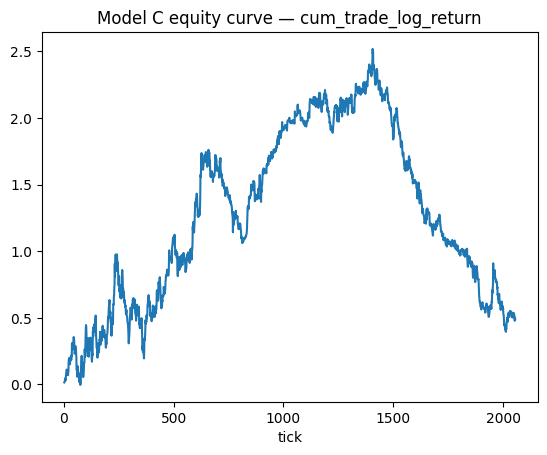

In [24]:
# 19:28 - Plotting cumulative return of online learning (Model C equity curve)
df_results['cum_trade_log_return'].plot(title='Model C equity curve — cum_trade_log_return')
plt.show()